In [1]:
import loompy as lp
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pdir = "/dcs04/lieber/marmaypag/spatialDLPFC_mdd_bpd_LIBD4100/spatialDLPFC_mdd_bpd/"
MODULE_PATH = pdir+"processed-data/09_SCENIC/AUCell_regulons/"

In [15]:
def extract_aucell(cluster):
    lf = lp.connect(MODULE_PATH+"spe-n119_seurat-label-"+cluster+"_13844-genes_no-lowUMI_logcounts_regulons-AUCell-fixed-thold-05.loom", mode='r+', validate=False)
    auc_mtx = pd.DataFrame(lf.ca.RegulonsAUC, index=lf.ca.CellID)
    cell_mtx = pd.DataFrame({"seurat_label": lf.ca.seurat_label, "smoothed_k9_1663": lf.ca.smoothed_k9_1663, #"custom_cluster": cluster,
                             "sex": lf.ca.sex, "condition": lf.ca.condition, "nGene": lf.ca.nGene, "nUMI": lf.ca.nUMI}, index=lf.ca.CellID)
    lf.close()
    
    #signature_column_names = list(auc_mtx.select_dtypes('number').columns)
    #signature_column_names = list(map(lambda s: s[12:], signature_column_names))
    #auc_mtx.columns = signature_column_names
    
    return auc_mtx, cell_mtx

In [17]:
auc_mv, cell_mv = extract_aucell("Micro.Vasc")
auc_ast, cell_ast = extract_aucell("Astro")
auc_l23, cell_l23 = extract_aucell("L2.3")
#auc_agl, cell_agl = extract_aucell("custom-cluster-", "Astro.Glia")
#auc_anr, cell_anr = extract_aucell("custom-cluster-", "Astro.Nrn")
#auc_l2, cell_l2 = extract_aucell("custom-cluster-", "L2")
#auc_l3, cell_l3 = extract_aucell("custom-cluster-", "L3")
auc_l4, cell_l4 = extract_aucell("L4")
auc_inh, cell_inh = extract_aucell("Inhb")
auc_l5, cell_l5 = extract_aucell("L5")
auc_l6, cell_l6 = extract_aucell("L6")
auc_wm, cell_wm = extract_aucell("Oligo")

In [18]:
auc_all = pd.concat([auc_mv, auc_ast, auc_l23, #auc_agl, auc_anr, auc_l2, auc_l3, 
                     auc_l4, auc_inh, auc_l5, auc_l6, auc_wm])
cell_all = pd.concat([cell_mv, cell_ast, cell_l23, #cell_agl, cell_anr, cell_l2, cell_l3, 
                      cell_l4, cell_inh, cell_l5, cell_l6, cell_wm])

In [19]:
joined_all = pd.concat([auc_all, cell_all], axis=1)
joined_all.shape

(513200, 36)

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
transfer_bright = {'Micro.Vasc': "#911223", 'Astro': "#cfa45c", 'L2.3': "#088F8F", 'L4': "#c2cfcf",
                   'Inhb': "#9377AC", 'L5': "#ddc94e", 'L6': "#E45C5F", 'Oligo': "#D1C4B0"}
smoothed_bright = {'Vasc': "#911223", 'L1': "#cfa45c", 'L2': "#5D9940", 'L3.4': "#5095CD",
                  'GABA': "#9377AC", 'L5': "#ddc94e", 'L6': "#E45C5F", 'WM': "#D1C4B0"}

In [20]:
auc_all.columns

Index(['ARX(+)', 'ATF4(+)', 'BCL6(+)', 'CEBPB(+)', 'CEBPD(+)', 'CUX2(+)',
       'DLX1(+)', 'ETS2(+)', 'FOS(+)', 'FOSB(+)', 'FOXC1(+)', 'GTF2I(+)',
       'JUN(+)', 'JUNB(+)', 'KLF2(+)', 'KLF4(+)', 'LHX6(+)', 'NFE2L1(+)',
       'NFIA(+)', 'NPAS4(+)', 'OLIG2(+)', 'PURA(+)', 'SOX10(+)', 'SOX18(+)',
       'SOX2(+)', 'SOX8(+)', 'SOX9(+)', 'SREBF1(+)', 'THRB(+)', 'ZBTB7A(+)'],
      dtype='object')

Text(0.5, 1.0, 'CUX2(+) by precast')

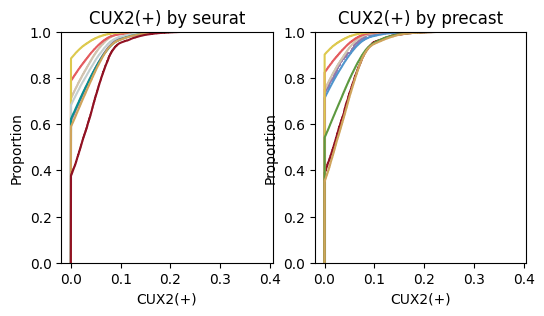

In [64]:
gene1 = "CUX2(+)" #49 module genes

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(6, 3))
sns.ecdfplot(data=joined_all, x=gene1, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax1)
ax1.set_title(gene1+" by seurat")
sns.ecdfplot(data=joined_all, x=gene1, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax2)
ax2.set_title(gene1+" by precast")


Text(0.5, 1.0, 'CUX2(+) by precast')

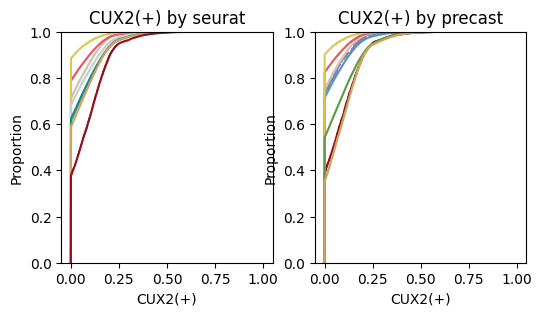

In [67]:
gene1 = "CUX2(+)" #49 module genes

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(6, 3))
sns.ecdfplot(data=joined_scale, x=gene1, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax1)
ax1.set_title(gene1+" by seurat")
sns.ecdfplot(data=joined_scale, x=gene1, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax2)
ax2.set_title(gene1+" by precast")

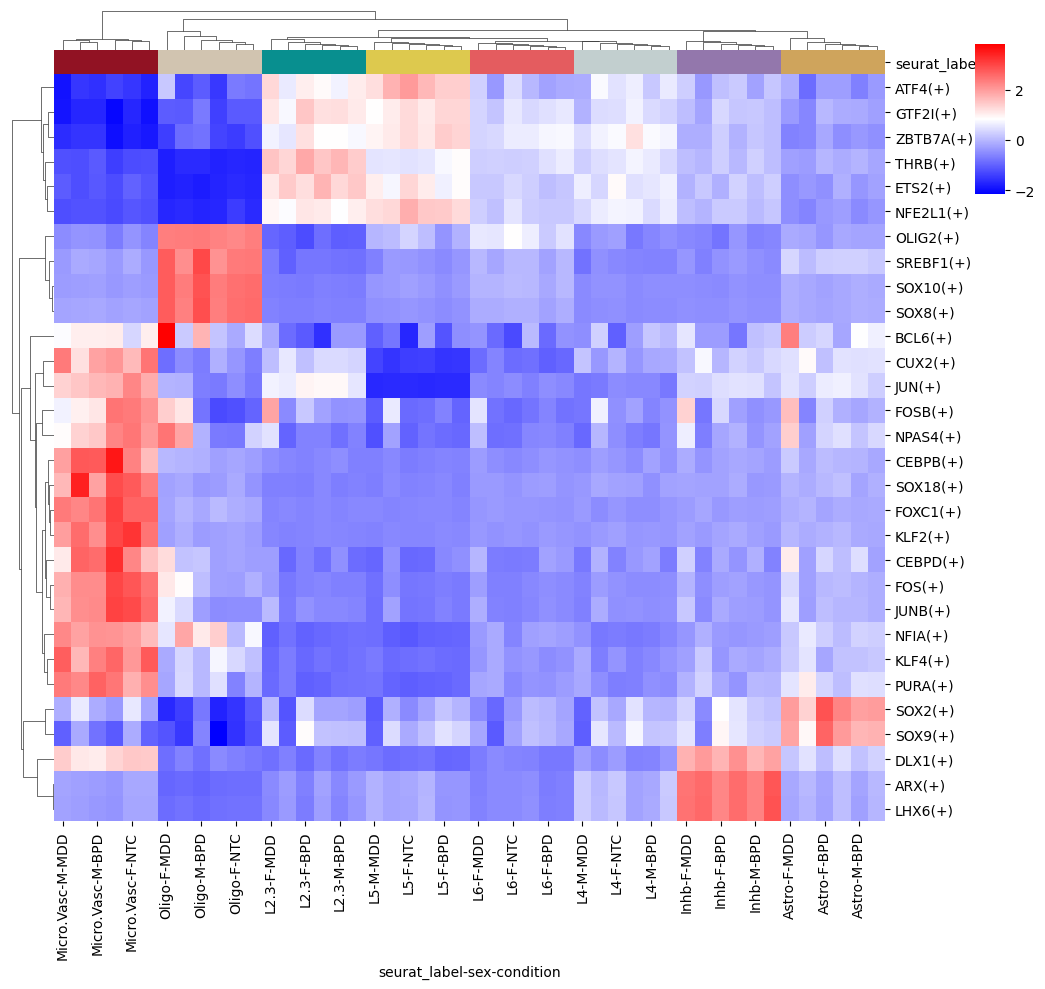

In [22]:
df_scores = joined_all[list(auc_all.select_dtypes('number').columns)+['seurat_label','sex','condition']]
df_means = df_scores.groupby(by=['seurat_label','sex','condition']).mean()

colors_df = pd.DataFrame(index=df_means.index)
colors_df['seurat_label'] = [x[0] for x in df_means.index]
row_colors = colors_df['seurat_label'].map(transfer_bright)

sns.clustermap(df_means.T, z_score='row', col_colors=row_colors, dendrogram_ratio=.05,
               cmap='bwr',
              cbar_pos=(0.98, 0.8, 0.03, 0.15))

In [30]:
joined_all.head()

,ARX(+),ATF4(+),BCL6(+),CEBPB(+),CEBPD(+),CUX2(+),DLX1(+),ETS2(+),FOS(+),FOSB(+),...,SOX9(+),SREBF1(+),THRB(+),ZBTB7A(+),seurat_label,smoothed_k9_1663,sex,condition,nGene,nUMI
TAGAATAGCCGATGAA-1_V13F27-338_A1,0.000000,0.127816,0.000000,0.000000,0.000000,0.000000,0.045602,0.065544,0.014745,0.027247,...,0.321978,0.035657,0.071562,0.000000,Micro.Vasc,L1,M,NTC,537,632.0
CAACCTACCGAGCAGT-1_V13F27-338_A1,0.000000,0.054401,0.009600,0.000000,0.002607,0.134023,0.074845,0.000000,0.012808,0.000000,...,0.154159,0.060356,0.103513,0.000000,Micro.Vasc,L1,M,NTC,296,358.0
GTCAACCAGGCCTATA-1_V13F27-338_A1,0.000000,0.123485,0.004672,0.000000,0.017339,0.028165,0.063099,0.000000,0.012861,0.061659,...,0.118250,0.002889,0.130432,0.227192,Micro.Vasc,L1,M,NTC,398,457.0
CTAGGTCTGAAGGAAT-1_V13F27-338_A1,0.062468,0.121626,0.000000,0.024705,0.021220,0.000000,0.011032,0.012052,0.018476,0.009925,...,0.419949,0.119837,0.135144,0.151825,Micro.Vasc,L2,M,NTC,1047,1399.0
CACCGTATCCCATCCG-1_V13F27-338_A1,0.021091,0.047436,0.007701,0.000000,0.059410,0.041471,0.013187,0.000000,0.023267,0.068116,...,0.247064,0.131000,0.066017,0.000000,Micro.Vasc,L1,M,NTC,332,370.0


In [59]:
auc_scale = auc_all / auc_all.max(axis=0)

In [60]:
joined_scale = pd.concat([auc_scale, cell_all], axis=1)
joined_scale.shape

(513200, 36)

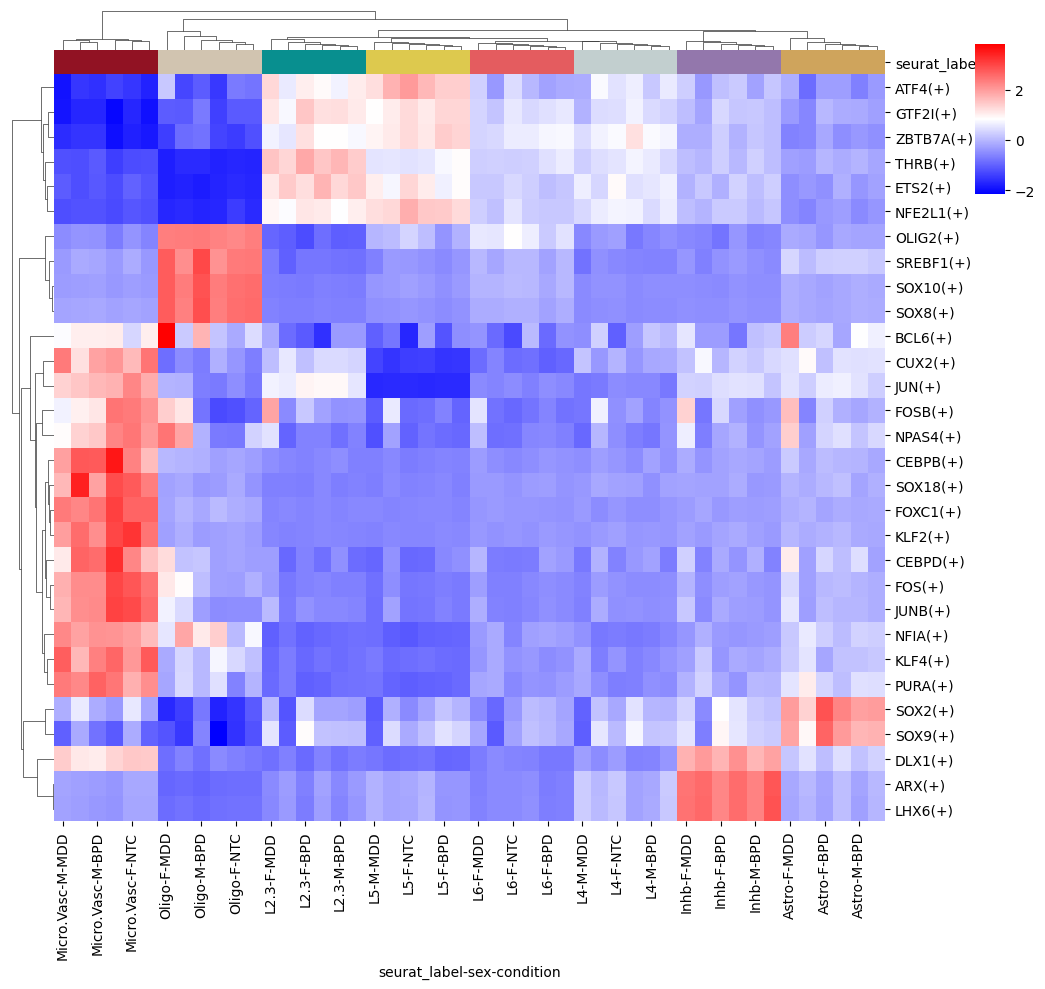

In [61]:
df_scores = joined_scale[list(auc_scale.select_dtypes('number').columns)+['seurat_label','sex','condition']]
df_means = df_scores.groupby(by=['seurat_label','sex','condition']).mean()

colors_df = pd.DataFrame(index=df_means.index)
colors_df['seurat_label'] = [x[0] for x in df_means.index]
row_colors = colors_df['seurat_label'].map(transfer_bright)

sns.clustermap(df_means.T, z_score='row', col_colors=row_colors, dendrogram_ratio=.05,
               cmap='bwr',
              cbar_pos=(0.98, 0.8, 0.03, 0.15))

In [40]:
from pyscenic.binarization import binarize

In [65]:
bin_all, thresholds_all = binarize(auc_scale)

/users/jthompso/.conda/envs/pyscenic_bioconda/lib/python3.10/site-packages/diptest/consts.py:702: UserWarning: Sample size exceeds the maximum limit of 72000. Results may not be accurate with precomputed statistical values.
  warnings.warn(
/users/jthompso/.conda/envs/pyscenic_bioconda/lib/python3.10/site-packages/diptest/consts.py:702: UserWarning: Sample size exceeds the maximum limit of 72000. Results may not be accurate with precomputed statistical values.
  warnings.warn(
/users/jthompso/.conda/envs/pyscenic_bioconda/lib/python3.10/site-packages/diptest/consts.py:702: UserWarning: Sample size exceeds the maximum limit of 72000. Results may not be accurate with precomputed statistical values.
  warnings.warn(
/users/jthompso/.conda/envs/pyscenic_bioconda/lib/python3.10/site-packages/diptest/consts.py:702: UserWarning: Sample size exceeds the maximum limit of 72000. Results may not be accurate with precomputed statistical values.
  warnings.warn(
/users/jthompso/.conda/envs/pyscenic

In [54]:
def plot_binarization(
    auc_mtx: pd.DataFrame, regulon_name: str, threshold: float, bins: int = 200, ax=None
) -> None:
    """
    Plot the "binarization" process for the given regulon.

    :param auc_mtx: The dataframe with the AUC values for all cells and regulons (n_cells x n_regulons).
    :param regulon_name: The name of the regulon.
    :param bins: The number of bins to use in the AUC histogram.
    :param threshold: The threshold to use for binarization.
    """
    if ax is None:
        ax = plt.gca()
    sns.histplot(auc_mtx[regulon_name], ax=ax, #norm_hist=True, 
                 bins=bins)

    ylim = ax.get_ylim()
    ax.plot([threshold] * 2, ylim, "r:")
    ax.set_ylim(ylim)
    ax.set_xlabel("AUC")
    ax.set_ylabel("#")
    ax.set_title(regulon_name)


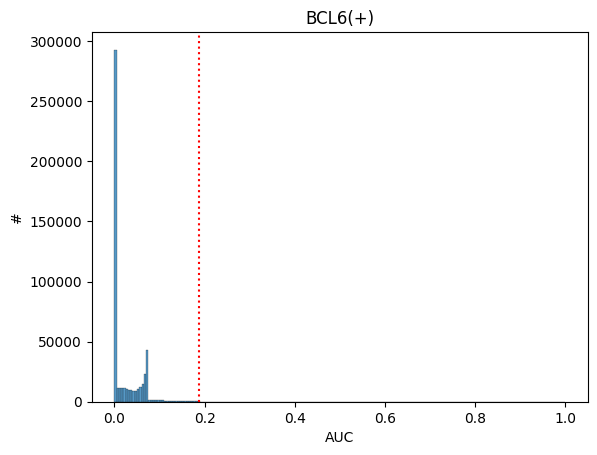

In [66]:
plot_binarization(auc_scale, "BCL6(+)", thresholds_all['BCL6(+)'])

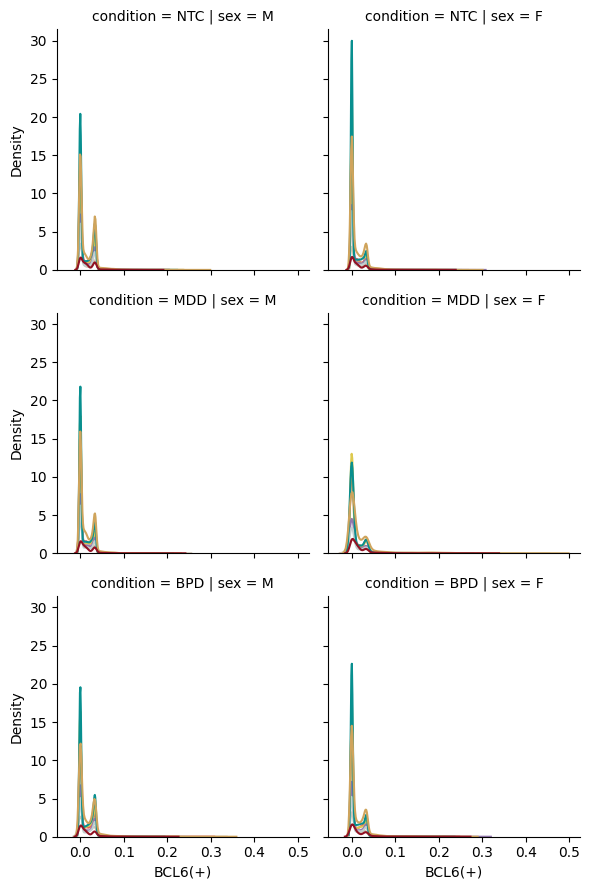

In [37]:
g = sns.FacetGrid(joined_all, col="sex",  row="condition")
g.map_dataframe(sns.kdeplot, x="BCL6(+)", hue="seurat_label", palette=transfer_bright)

In [34]:
joined_all['BCL6(+)']

TAGAATAGCCGATGAA-1_V13F27-338_A1    0.000000
CAACCTACCGAGCAGT-1_V13F27-338_A1    0.009600
GTCAACCAGGCCTATA-1_V13F27-338_A1    0.004672
CTAGGTCTGAAGGAAT-1_V13F27-338_A1    0.000000
CACCGTATCCCATCCG-1_V13F27-338_A1    0.007701
                                      ...   
CCAGTCTAGACGGCGC-1_V13B23-282_D1    0.000000
TCGCTTTAAACGTTTG-1_V13B23-282_D1    0.001027
AGTTACTCTATCGTGG-1_V13B23-282_D1    0.015813
GTGGCTGTTTCTGTTC-1_V13B23-282_D1    0.001643
CGTCGGATAGTGTTGA-1_V13B23-282_D1    0.016737
Name: BCL6(+), Length: 513200, dtype: float64